In [1]:
import os
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


In [3]:
base_dir = '/scratch/yl75/ak4177/results/groundwater/GINO/static_sampling/training_20260615_184635'
# base_dir = '/scratch/yl75/ak4177/results/groundwater/GINO/masked_no_sampling/training_20260611_121508'
train_preds = np.load(os.path.join(base_dir, 'train_preds.npy'))
train_targets = np.load(os.path.join(base_dir, 'train_targets.npy'))

val_preds = np.load(os.path.join(base_dir, 'val_preds.npy'))
val_targets = np.load(os.path.join(base_dir, 'val_targets.npy'))

train_targets[...,0] = train_targets[...,0]/1000
train_preds[...,0] = train_preds[...,0]/1000
val_targets[...,0] = val_targets[...,0]/1000
val_preds[..., 0] = val_preds[...,0]/1000

In [4]:
train_targets.mean(axis=(0, 1)), val_targets.mean(axis=(0, 1)), train_targets.shape

(array([18.40526038,  0.33618928]),
 array([18.43976976,  0.35715789]),
 (30683, 1331, 2))

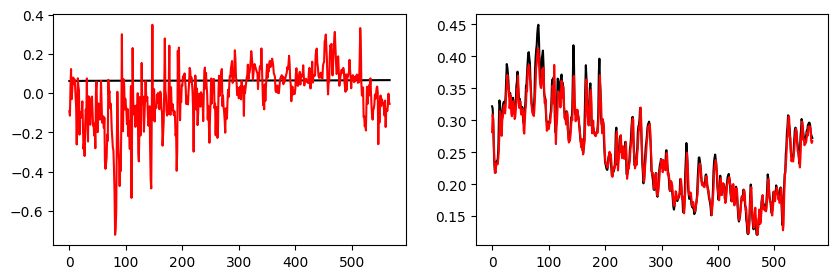

In [5]:
randidx = np.random.randint(train_preds.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(val_targets[randidx, :, 0], label='FEFLOW', c='black')
axes[0].plot(val_preds[randidx, :, 0], label='GINO', c='red')

axes[1].plot(val_targets[randidx, :, 1], label='FEFLOW', c='black')
axes[1].plot(val_preds[randidx, :, 1], label='GINO', c='red')

In [6]:
def np_l2_norm_error(preds, targets):
    return np.linalg.norm(preds - targets, ord=2, axis=1) / np.linalg.norm(targets, axis=1, ord=2)

def r2_score(preds, targets):
    ss_res = np.sum((targets - preds) ** 2, axis=1)
    ss_tot = np.sum((targets - np.mean(targets, axis=1, keepdims=True)) ** 2, axis=1)
    print(ss_tot)
    return 1 - (ss_res / ss_tot)

def signed_error(preds, targets):
    return np.mean(preds - targets, axis=1)

def mae(preds, targets):
    return np.mean(np.abs(preds - targets), axis=1)

In [11]:
patch_data_path = '/scratch/yl75/ak4177/data/feflow_data/patch_all_ts/'
coords_all = []
for patch_dir in sorted(os.listdir(patch_data_path)):
    coords_path = os.path.join(patch_data_path, patch_dir, 'core_coords.npy')
    coords_arr = np.load(coords_path)
    coords_all.append(coords_arr)

coords_arr = np.concatenate(coords_all, axis=0)
print(coords_arr.shape, val_preds.shape)

(61360, 3) (30683, 568, 2)


In [28]:
# Extract mass concentration time-series
mass_conc_preds = val_preds[..., 0]
mass_conc_targets = val_targets[..., 0]

In [29]:
(mass_conc_preds - mass_conc_targets).shape

(61360, 568)

ValueError: 'c' argument has 61360 elements, which is inconsistent with 'x' and 'y' with size 3409.

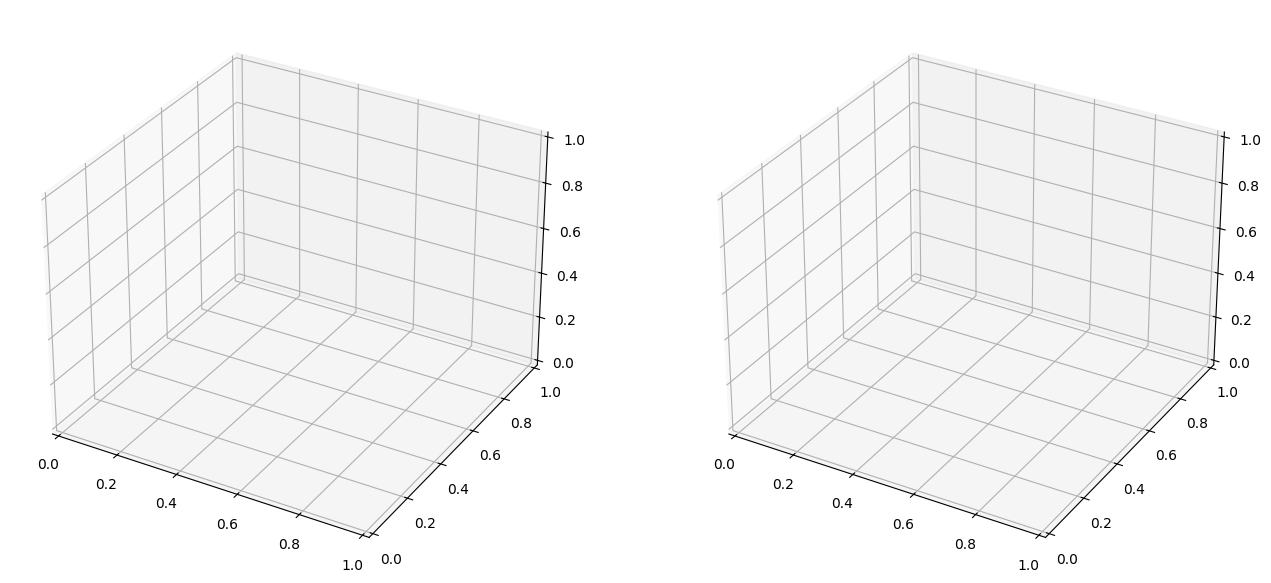

In [30]:
# Plot final time step error for mass concentration and hydraulic head in 3D scatter plot
fig, axs = plt.subplots(1, 2, figsize=(16, 12), subplot_kw={'projection': '3d'})

vmin, vmax = mass_conc_targets[:, -1].min(), mass_conc_targets[:, -1].max()

cmap_black_red = LinearSegmentedColormap.from_list('black_red', ['black', 'red'])


# Plotting
sc1 = axs[0].scatter(coords_arr[:, 0], coords_arr[:, 1], coords_arr[:, 2], 
                    c=mass_conc_targets[:, -1], cmap=cmap_black_red, alpha=0.5, s=10, vmin=vmin, vmax=vmax)

axs[0].set_title('Mass Concentration ')
axs[0].set_xlabel('X Coordinate (m)')
axs[0].set_ylabel('Y Coordinate (m)')

plt.colorbar(sc1, ax=axs[0], shrink=0.3)


# Plotting
sc2 = axs[1].scatter(coords_arr[:, 0], coords_arr[:, 1], coords_arr[:, 2], 
                    c=mass_conc_preds[:, -1], cmap=cmap_black_red, alpha=0.5, s=10, vmin=vmin, vmax=vmax)

axs[1].set_title('Mass Concentration ')
axs[1].set_xlabel('X Coordinate (m)')
axs[1].set_ylabel('Y Coordinate (m)')

for ax in axs:
    # Aspect Ratio
    ax.set_box_aspect((1, 1, 1.1))
    
    # View Angle
    ax.view_init(elev=40, azim=180)
    
    # Padding
    ax.xaxis.labelpad = 15
    ax.yaxis.labelpad = 10
    ax.zaxis.labelpad = 5

plt.colorbar(sc2, ax=axs[1], shrink=0.3)

In [ ]:

# Plot final time step error for mass concentration and hydraulic head in 3D scatter plot
# CHANGED: Reduced the height from 12 to 6 to eliminate the massive vertical white space
fig, axs = plt.subplots(1, 3, figsize=(14, 6), subplot_kw={'projection': '3d'})

fig.suptitle('Mass Concentration Test Data Performance')

# MAE for mass concentration
mae_mass_conc = mae(mass_conc_preds, mass_conc_targets)

# L2 norm error for mass concentration
l2_mass_conc = np_l2_norm_error(mass_conc_preds, mass_conc_targets)

# Signed Error for mass concentration
signed_err_mass_conc = signed_error(mass_conc_preds, mass_conc_targets)

# 1. Define your custom colormaps
# Replaces 'Reds' (Black -> Red)
cmap_black_red = LinearSegmentedColormap.from_list('black_red', ['black', 'red'])

# Replaces 'coolwarm' (Blue -> Black -> Red)
cmap_blue_black_red = LinearSegmentedColormap.from_list('blue_black_red', ['blue', 'black', 'red'])


# Plotting MAE (Sequential)
sc = axs[0].scatter(coords_arr[:, 0], coords_arr[:, 1], coords_arr[:, 2], 
                    c=mae_mass_conc, cmap=cmap_black_red, alpha=0.5, s=10)
axs[0].set_title('MAE')
axs[0].set_xlabel('X Coordinate (m)')
# CHANGED: plt.colorbar -> fig.colorbar to fix the UserWarning
fig.colorbar(sc, ax=axs[0], shrink=0.3) 


# Plot Signed Error (Diverging)
sc1 = axs[1].scatter(coords_arr[:, 0], coords_arr[:, 1], coords_arr[:, 2], 
                    c=signed_err_mass_conc, cmap=cmap_blue_black_red, alpha=0.5, s=10) 
                    # ^ CHANGED: c=cmap_blue_black_red was changed to c=signed_err_mass_conc
axs[1].set_title('Signed Error (Pred - Target)')
axs[1].set_xlabel('X Coordinate (m)')
fig.colorbar(sc1, ax=axs[1], shrink=0.3)


# Plot L2 norm error (Sequential)
sc2 = axs[2].scatter(coords_arr[:, 0], coords_arr[:, 1], coords_arr[:, 2], 
                    c=l2_mass_conc, cmap=cmap_black_red, alpha=0.5, s=10)
axs[2].set_title('L2 Norm Error')
axs[2].set_xlabel('X Coordinate (m)')
fig.colorbar(sc2, ax=axs[2], shrink=0.3)

# Mass Concentration plot Mean Values
mean_mass_conc = np.mean(mass_conc_targets, axis=1)

# Mass Concentration plot Standard Deviation Values
std_mass_conc = np.std(mass_conc_targets, axis=1)

for ax in axs:
    # Aspect Ratio
    ax.set_box_aspect((1, 1, 1.1))

    # View Angle
    ax.view_init(elev=40, azim=180)

    # Padding
    ax.xaxis.labelpad = 15
    ax.yaxis.labelpad = 10
    ax.zaxis.labelpad = 5

# CHANGED: Added tight_layout to automatically adjust subplots and remove unnecessary padding
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.gridspec as gridspec

def plot_node_time_series(selected_index, title):
    
    # 1. Create a figure (increased width slightly to fit everything nicely)
    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(f"{title}\n L2 Error - {l2_mass_conc[selected_index]:.2f}, MAE - {mae_mass_conc[selected_index]:.2f}")
    gs = gridspec.GridSpec(nrows=1, ncols=3, width_ratios=[1.25, 1.25, 1])
    
    
    # 2. Add the subplots individually to mix 2D and 3D projections
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[0, 2], projection='3d')  # Only this one is 3D
    
    # --- Plot 1: Mass Concentration ---
    ax0.plot(val_targets[selected_index, :, 0], label='FEFLOW', c='black')
    ax0.plot(val_preds[selected_index, :, 0], label='GINO', c='red')
    ax0.set_ylabel(r'Mass Concentration $(\mathrm{kg/m}^3)$')
    ax0.set_xlabel('Time Step')
    ax0.set_title('Mass Concentration')
    ax0.legend()
    
    # --- Plot 2: Hydraulic Head ---
    ax1.plot(val_targets[selected_index, :, 1], label='FEFLOW', c='black')
    ax1.plot(val_preds[selected_index, :, 1], label='GINO', c='red')
    ax1.set_ylabel(r'Hydraulic Head $(m)$')
    ax1.set_xlabel('Time Step')
    ax1.set_title('Hydraulic Head')
    ax1.legend()
    
    # --- Plot 3: 3D Domain Context ---
    # Plot the full domain as a faint, transparent background
    scat = ax2.scatter(coords_arr[:, 0], coords_arr[:, 1], coords_arr[:, 2], 
                c=mass_conc_targets[:, -1], cmap=cmap_black_red, alpha=0.3, s=5)
    
    # Extract coordinates for the selected static node and highlight it
    sel_x, sel_y, sel_z = coords_arr[selected_index]
    ax2.scatter(sel_x, sel_y, sel_z, 
                c='red', marker='*', alpha=1.0, s=50, edgecolors='red', label='Selected Node')
    
    ax2.set_title('Mass Concentration (FEFLOW)')
    ax2.set_xlabel('X (m)')
    # ax2.set_ylabel('Y (m)')
    ax2.set_zlabel('Z (m)')

    fig.colorbar(scat, ax=ax2, shrink=0.7, pad=0.1)
    ax2.legend(loc='upper right')
    
    # Optional: Adjust the view angle for better visibility
    # Aspect Ratio
    ax2.set_box_aspect((1, 1, 1.1))
    
    # View Angle
    ax2.view_init(elev=45, azim=160)
    
    # Padding
    ax2.xaxis.labelpad = 15
    ax2.yaxis.labelpad = 10
    ax2.zaxis.labelpad = 5
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Find the static node index
high_l2_idx = np.argsort(l2_mass_conc)[-1]
title = f'High L2-Error Node'
plot_node_time_series(high_l2_idx, title)

In [ ]:
# Find the static node index
static_idx = np.argsort(np.abs(np.diff(mass_conc_targets, axis=1)).mean(axis=-1))[1]
title = 'Static Node - Test Data Performance'
plot_node_time_series(static_idx, title)

In [ ]:
high_fluctuation_idx = np.random.choice((np.where((mass_conc_targets.max(axis=1)>=35) &\
                                                  (mass_conc_targets.min(axis=1)<=20))[0]))
title = 'High-fluctuation Node - Test Data Performance'
plot_node_time_series(high_fluctuation_idx, title)

In [ ]:
mean_abs_diff = np.abs(np.diff(mass_conc_targets, axis=1)).mean(axis=-1)
median_diff_idx = np.argsort(mean_abs_diff)[int(mean_abs_diff.shape[0]/2)]
title = 'Median Rate of Change Node - Test Data Performance'
plot_node_time_series(median_diff_idx, title)

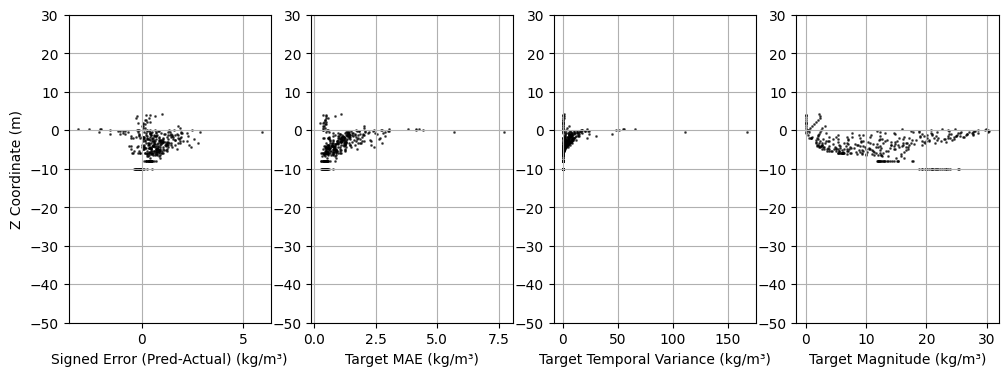

In [14]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))

filter_mask = mae_mass_conc > 0

# Plot error vs z coordinate
ax[0].scatter(signed_err_mass_conc[filter_mask], coords_arr[filter_mask, 2], alpha=0.6, color='black', s=1)
ax[0].set_ylabel('Z Coordinate (m)')
ax[0].set_xlabel('Signed Error (Pred-Actual) (kg/m³)')
ax[0].set_ylim(-50, 30)
# plt.colorbar(ax[0].collections[0], ax=ax[0], shrink=1.0, aspect=50)
ax[0].grid()

# Plot mae vs z coordinate
sc2 = ax[1].scatter(mae_mass_conc[filter_mask], coords_arr[filter_mask, 2], alpha=0.6, s=1, color='black')
ax[1].set_xlabel('Target MAE (kg/m³)')
# plt.colorbar(sc2, ax=ax[1], shrink=1.0, aspect=50)
ax[1].set_ylim(-50, 30)
ax[1].grid()

# # Plot L2 norm error vs z coordinate
# sc2 = ax[2].scatter(l2_mass_conc[filter_mask], coords_arr[filter_mask, 2], alpha=0.6, s=1, color='black')
# ax[2].set_xlabel('Target L2 Norm Error')
# # plt.colorbar(sc2, ax=ax[2], shrink=1.0, aspect=50)
# ax[2].set_ylim(-50, 30)
# ax[2].grid()

# Plot magnitude vs z coordinate
sc3 = ax[3].scatter(mean_mass_conc[filter_mask], coords_arr[filter_mask, 2], alpha=0.6, s=1, color='black')
ax[3].set_xlabel('Target Magnitude (kg/m³)')
# plt.colorbar(sc3, ax=ax[3], shrink=1.0, aspect=50)
ax[3].set_ylim(-50, 30)
ax[3].grid()


# Plot standard deviation vs z coordinate
sc3 = ax[2].scatter(np.square(std_mass_conc[filter_mask]), coords_arr[filter_mask, 2], alpha=0.6, s=1, color='black')
ax[2].set_xlabel('Target Temporal Variance (kg/m³)')
# plt.colorbar(sc3, ax=ax[2], shrink=1.0, aspect=50)
ax[2].set_ylim(-50, 30)
ax[2].grid()


plt.show()

## 2D Cross-Section of Mass Concentration (Patch)

Uses the **same FEM mesh geometry** and **same P1→P2 plane** as `cross_section_analysis.ipynb` and `create_cross_section_video.py`.
The ASCII mesh triangulation is used to find exact cross-section panels within the patch bounding box,
and `tricontourf` renders the result with the FEFLOW colour map.

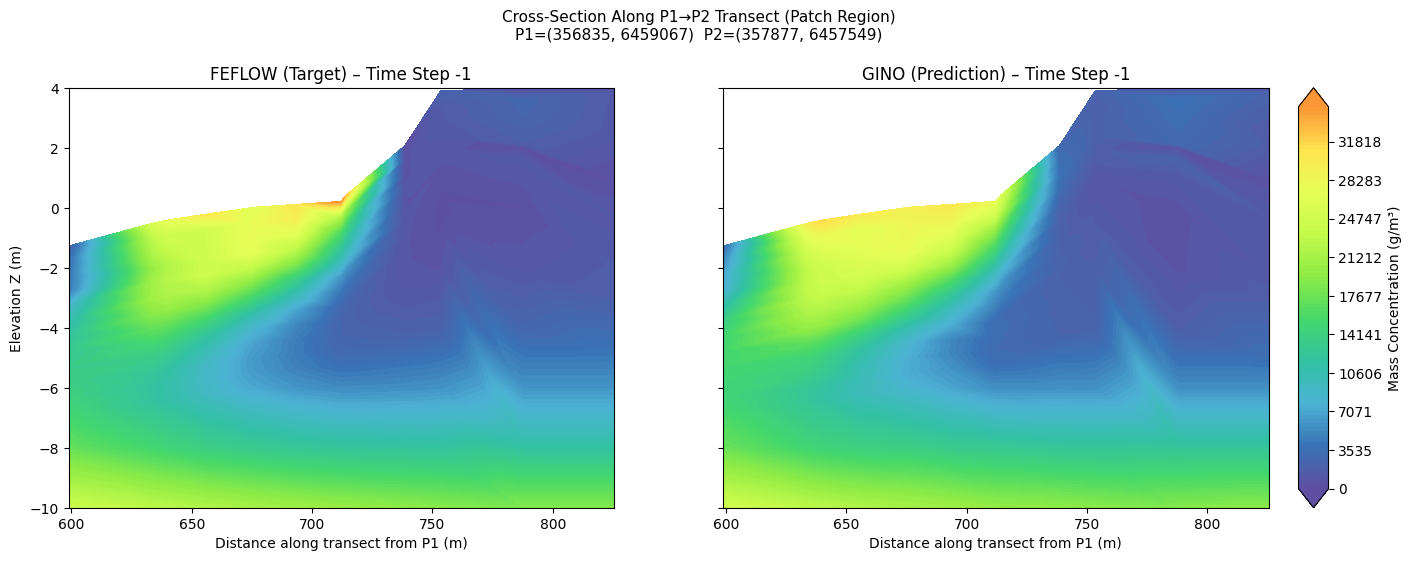

In [16]:
import matplotlib.tri as mtri
import matplotlib.colors as mcolors
from scipy.spatial import KDTree

# ── Cross-section plane (same P1/P2 as cross_section_analysis.ipynb) ─────────
p1_cs = np.array([356835.28, 6459067.43])
p2_cs = np.array([357877.28, 6457548.86])
dx_L  = p2_cs[0] - p1_cs[0]
dy_L  = p2_cs[1] - p1_cs[1]
cs_length = np.hypot(dx_L, dy_L)

# ── Parse ASCII mesh ──────────────────────────────────────────────────────────
fem_path = '/scratch/yl75/ak4177/data/feflow_data/ascii_mesh.fem'
n2d = 2360
elements_2d, coor_vals = [], []
in_node = in_coor = False
with open(fem_path, 'r', errors='ignore') as _f:
    for _l in _f:
        _l = _l.strip()
        if _l == 'NODE':  in_node = True;  continue
        if in_node and len(_l)>0 and _l[0].isalpha() and _l[0].isupper(): in_node = False
        elif in_node:
            _ns = [int(_n)-1 for _n in _l.split()]
            if _ns[0] < n2d: elements_2d.append(_ns[:3])
        if _l == 'COOR':  in_coor = True;  continue
        if in_coor and len(_l)>0 and _l[0].isalpha() and _l[0].isupper(): in_coor = False
        elif in_coor:
            for _p in _l.split(','):
                if _p.strip(): coor_vals.append(float(_p))

x_mesh = np.array(coor_vals[:n2d])
y_mesh = np.array(coor_vals[n2d:2*n2d])
elements_2d = np.array(elements_2d)

# ── Apply correct UTM shift (full-domain minimum, same as cross_section_analysis.ipynb) ─
FULL_X_MIN = 355702.3992551436   # unnorm_coords[:,0].min() for full domain
FULL_Y_MIN = 6456013.4359585     # unnorm_coords[:,1].min() for full domain
x_utm = x_mesh + (FULL_X_MIN - x_mesh.min())
y_utm = y_mesh + (FULL_Y_MIN - y_mesh.min())
xy_2d = np.column_stack((x_utm, y_utm))

# ── Find mesh triangles whose centroid lies within the patch bounding box ─────
px_min, px_max = coords_arr[:,0].min()-5, coords_arr[:,0].max()+5
py_min, py_max = coords_arr[:,1].min()-5, coords_arr[:,1].max()+5
cx = x_utm[elements_2d].mean(axis=1)
cy = y_utm[elements_2d].mean(axis=1)
in_patch_mask = (cx>=px_min)&(cx<=px_max)&(cy>=py_min)&(cy<=py_max)

# ── Find cross-section panels (FEM-exact intersections) ──────────────────────
intersecting_panels_cs = []
for _elem in elements_2d[in_patch_mask]:
    _pts = xy_2d[_elem]
    _hits = []
    for _i, _j in [(0,1),(1,2),(2,0)]:
        A, B = _pts[_i], _pts[_j]
        dx_E = B[0]-A[0]; dy_E = B[1]-A[1]
        det = dx_L*dy_E - dy_L*dx_E
        if abs(det)<1e-10: continue
        dx_AP = A[0]-p1_cs[0]; dy_AP = A[1]-p1_cs[1]
        t_L = (dx_AP*dy_E - dy_AP*dx_E)/det
        t_E = (dx_AP*dy_L - dy_AP*dx_L)/det
        if 0<=t_L<=1 and -1e-5<=t_E<=1+1e-5:
            _hits.append((t_L, t_E, _elem[_i], _elem[_j]))
    if len(_hits)>=2:
        _hits.sort(key=lambda x: x[0])
        h1, h2 = _hits[0], _hits[-1]
        if h2[0]-h1[0]>1e-5:
            intersecting_panels_cs.append({
                's1': h1[0]*cs_length, 'w1': h1[1], 'e1': (h1[2], h1[3]),
                's2': h2[0]*cs_length, 'w2': h2[1], 'e2': (h2[2], h2[3])
            })

# ── Map the MESH 2D nodes → PATCH 3D nodes via KDTree ────────────────────────
num_slices_patch = 15   # max z-levels in this patch
_tree = KDTree(coords_arr[:, :2])
_, _idx_all = _tree.query(xy_2d, k=num_slices_patch)
mapped_idx = np.zeros((n2d, num_slices_patch), dtype=int)
for _i in range(n2d):
    _vi = _idx_all[_i]
    mapped_idx[_i] = _vi[np.argsort(coords_arr[_vi, 2])]

# ── Build 2D cross-section geometry and interpolate values ───────────────────
# mass_conc_preds / mass_conc_targets are in g/m³, shape (346, T)
mc_preds_ts   = val_preds[..., 0]*1000   # (N, T)
mc_targets_ts = val_targets[..., 0]*1000

s_cs_arr, z_cs_arr = [], []
node_preds_cs, node_targets_cs = [], []
tris_cs = []
nc = 0
for _panel in intersecting_panels_cs:
    s1, w1, e1 = _panel['s1'], _panel['w1'], _panel['e1']
    s2, w2, e2 = _panel['s2'], _panel['w2'], _panel['e2']
    for k in range(num_slices_patch):
        a1, b1_ = mapped_idx[e1[0],k], mapped_idx[e1[1],k]
        a2, b2_ = mapped_idx[e2[0],k], mapped_idx[e2[1],k]
        z1 = coords_arr[a1,2] + w1*(coords_arr[b1_,2]-coords_arr[a1,2])
        z2 = coords_arr[a2,2] + w2*(coords_arr[b2_,2]-coords_arr[a2,2])
        p1t = mc_preds_ts[a1]+w1*(mc_preds_ts[b1_]-mc_preds_ts[a1])
        p2t = mc_preds_ts[a2]+w2*(mc_preds_ts[b2_]-mc_preds_ts[a2])
        t1t = mc_targets_ts[a1]+w1*(mc_targets_ts[b1_]-mc_targets_ts[a1])
        t2t = mc_targets_ts[a2]+w2*(mc_targets_ts[b2_]-mc_targets_ts[a2])
        s_cs_arr.extend([s1, s2]); z_cs_arr.extend([z1, z2])
        node_preds_cs.append(p1t); node_preds_cs.append(p2t)
        node_targets_cs.append(t1t); node_targets_cs.append(t2t)
        if k > 0:
            tris_cs += [[nc-2,nc-1,nc],[nc-1,nc+1,nc]]
        nc += 2

s_cs_arr       = np.array(s_cs_arr)
z_cs_arr       = np.array(z_cs_arr)
tris_cs        = np.array(tris_cs)
preds_cs_all   = np.array(node_preds_cs)    # (N_cs_nodes, T)
targets_cs_all = np.array(node_targets_cs)

# ── FEFLOW colour map ──────────────────────────────────────────────────────────
feflow_colors = ['#5E4FA2','#3973B5','#4CB2D4','#32C2A3','#45D86A',
                 '#8DEB45','#C4FA4B','#E7FE57','#FEE44F','#FB9736']
feflow_cmap = mcolors.LinearSegmentedColormap.from_list('feflow', feflow_colors)
feflow_norm = mcolors.Normalize(vmin=0, vmax=35000)
contour_kw  = dict(levels=np.linspace(0, 35000, 100), cmap=feflow_cmap, norm=feflow_norm, extend='both')

triangulation_cs = mtri.Triangulation(s_cs_arr, z_cs_arr, tris_cs)

# ── Plot (final time step) ─────────────────────────────────────────────────────
T_idx = -1   # change to any timestep index
fig_cs, axes_cs = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

axes_cs[0].tricontourf(triangulation_cs, targets_cs_all[:, T_idx], **contour_kw)
axes_cs[0].set_title(f'FEFLOW (Target) – Time Step {T_idx}')
axes_cs[0].set_ylabel('Elevation Z (m)')
axes_cs[0].set_xlabel('Distance along transect from P1 (m)')

cf = axes_cs[1].tricontourf(triangulation_cs, preds_cs_all[:, T_idx], **contour_kw)
axes_cs[1].set_title(f'GINO (Prediction) – Time Step {T_idx}')
axes_cs[1].set_xlabel('Distance along transect from P1 (m)')

fig_cs.subplots_adjust(right=0.88, left=0.08, bottom=0.15, top=0.85)
cbar_ax = fig_cs.add_axes([0.90, 0.15, 0.02, 0.7])
fig_cs.colorbar(cf, cax=cbar_ax, label='Mass Concentration (g/m³)', extend='both')

plt.suptitle(
    f'Cross-Section Along P1→P2 Transect (Patch Region)\n'
    f'P1=({p1_cs[0]:.0f}, {p1_cs[1]:.0f})  '
    f'P2=({p2_cs[0]:.0f}, {p2_cs[1]:.0f})',
    fontsize=11
)
plt.show()